# OceanoIA — 03_RNN_Oceanografia
# Predicción Oceanográfica: Exploración del Modelo y Resultados

Este notebook contiene:
- Los pasos del pipeline
- Entrena los 3 modelos (oleaje, marea, SST)
- Visualiza predicciones y compara metricas


## 1. Importar el modulo de entrenamiento

Se importa el modulo desde train que guarda el entrenamiento de este y muestra las funciones que estan disponibles


In [15]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raíz del proyecto (carpeta que contiene 'src' y 'data')
ruta = os.path.abspath('.')
while ruta != os.path.dirname(ruta):
    if os.path.isdir(os.path.join(ruta, 'src')) and os.path.isdir(os.path.join(ruta, 'data')):
        BASE_DIR = ruta
        break
    ruta = os.path.dirname(ruta)
else:
    BASE_DIR = os.path.abspath('..')

# Conectar con rnn.py (src/train)
sys.path.insert(0, os.path.join(BASE_DIR, 'src', 'train'))
import rnn

RUTA_CSV = os.path.join(BASE_DIR, 'data', 'processed', 'oceano_merged.csv')

# *** LA LÍNEA CLAVE: parchear el default de cargar_datos ***
rnn.cargar_datos.__defaults__ = (RUTA_CSV,)

# Redirigir también constantes de ruta de modelos (por si guarda en src/train/models)
def _reanclar(valor):
    v = valor.replace('\\', '/')
    for carpeta in ('data', 'models'):
        idx = v.find(f'/{carpeta}/')
        if idx != -1:
            return os.path.join(BASE_DIR, *v[idx + 1:].split('/'))
    return valor

for nombre in dir(rnn):
    val = getattr(rnn, nombre)
    if isinstance(val, str) and ('/' in val or '\\' in val):
        nuevo = _reanclar(val)
        if nuevo != val:
            setattr(rnn, nombre, nuevo)

print("CSV existe?:", os.path.exists(RUTA_CSV))
print("Default de cargar_datos:", rnn.cargar_datos.__defaults__)

CSV existe?: True
Default de cargar_datos: ('C:\\Users\\Daniel Nájera\\Documents\\GitHub\\OceanoIA\\data\\processed\\oceano_merged.csv',)


## 2. Cargar y revisar los datos

Aqui se reutiliza `train.cargar_datos()` y `train.preparar_features()`  para garantizar que
estamos viendo exactamente los mismos datos que se le dan al modelo porque las
mismas funciones que usa el entrenamiento real,


In [16]:
df = rnn.cargar_datos(RUTA_CSV)          # se le pasa la ruta correcta
df, features = rnn.preparar_features(df)

print('Filas:', df.shape[0], '| Columnas:', df.shape[1])
print('Rango de fechas:', df.index.min().date(), '->', df.index.max().date())
print('Features disponibles para el modelo:', features)
df[features].head()

Filas: 517 | Columnas: 12
Rango de fechas: 2025-01-01 -> 2026-06-01
Features disponibles para el modelo: ['Oleaje_m', 'Periodo_Oleaje_s', 'Direccion_Oleaje_deg', 'Marea_m', 'SST_Copernicus', 'temp_aire_c', 'viento_kmh', 'presion_hpa', 'humedad_pct', 'nubosidad_octas']


,Oleaje_m,Periodo_Oleaje_s,Direccion_Oleaje_deg,Marea_m,SST_Copernicus,temp_aire_c,viento_kmh,presion_hpa,humedad_pct,nubosidad_octas
Fecha,,,,,,,,,,
2025-01-01,0.376667,8.060417,190.000000,0.334583,27.862621,22.6,11.2,1009.6,72.0,6.0
2025-01-02,0.352500,10.320833,192.291667,0.337500,28.053205,22.6,12.7,1010.6,71.0,6.0
2025-01-03,0.405833,11.954167,191.625000,0.359583,27.944519,22.6,11.9,1010.7,70.0,5.0
2025-01-04,0.436667,10.829167,188.833333,0.394583,27.935103,22.6,11.5,1010.6,71.0,6.0
2025-01-05,0.407500,10.129167,187.166667,0.409583,28.068752,22.8,11.7,1010.4,73.0,5.0


## 3. Configuración

La ventana (`WINDOW_IN`/`WINDOW_OUT`) y la arquitectura estan como
valores por defecto en `train.py` `window_in=30` y `window_out=3`esto es
equivalente a 72 horas con datos diarios.


Aquí solo se muestran



In [17]:
print("Ventana de entrada (días históricos):", 30)
print("Horizonte de predicción (días, ~72h):", 3)
print("Arquitectura: LSTM(100) -> LSTM(50) -> Dropout(0.2) -> Dense(3)")


Ventana de entrada (días históricos): 30
Horizonte de predicción (días, ~72h): 3
Arquitectura: LSTM(100) -> LSTM(50) -> Dropout(0.2) -> Dense(3)


## 4. Entrenar el modelo de oleaje


Esto entrena, evalúa contra el baseline, reentrena con todos los datos,
y guarda `models/lstm_oleaje_m.keras`


In [18]:
modelo_oleaje, scaler_oleaje, metricas_oleaje = rnn.entrenar(target="Oleaje_m")

print("\nResumen de métricas — Oleaje_m:")
for k, v in metricas_oleaje.items():
    print(f"  {k}: {v:.3f}")


=== Entrenando modelo LSTM — target: Oleaje_m ===

Train: 380 secuencias | Test: 71 secuencias


C:\Users\Daniel Nájera\Documents\GitHub\OceanoIA\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

 Trainable params: 74,753 (292.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0347 - mae: 0.1415 - val_loss: 0.0105 - val_mae: 0.0824
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0176 - mae: 0.1033 - val_loss: 0.0068 - val_mae: 0.0659
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0157 - mae: 0.0982 - val_loss: 0.0097 - val_mae: 0.0815
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0153 - mae: 0.0969 - val_loss: 0.0084 - val_mae: 0.0752
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0152 - mae: 0.0943 - val_loss: 0.0094 - val_mae: 0.0805
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0133 - mae: 0.0903 - val_loss: 0.0104 - val_mae: 0.0852
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0133 - mae: 0.0883 - val_loss: 0.0091 - val_mae: 0.0792
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0138 - mae: 0.0899 - val_loss: 0.0090 - val_mae: 0.0789
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - lo

C:\Users\Daniel Nájera\Documents\GitHub\OceanoIA\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0299 - mae: 0.1289
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0166 - mae: 0.0995
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0151 - mae: 0.0967
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0140 - mae: 0.0919
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0145 - mae: 0.0941
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0131 - mae: 0.0883
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0129 - mae: 0.0882
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0126 - mae: 0.0876
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0122 - mae: 0.0860
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0124 - mae: 0.0869
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0113 - mae: 0.0821
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0125 - mae: 0.0857
Epoch 13/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/s

## 5. Visualizar el pronóstico del modelo de oleaje

Se reutilizan `train.crear_secuencias()` y `train.desescalar_target()`
para armar la ventana mas reciente y graficar el pronostico de los
próximos 3 dias



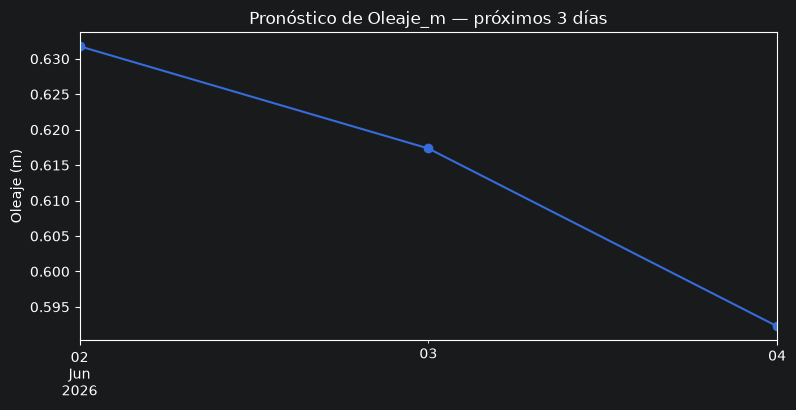

2026-06-02    0.631767
2026-06-03    0.617348
2026-06-04    0.592262
Freq: D, Name: Oleaje_m_pred, dtype: float64

In [19]:
data_oleaje = df[features].values
target_idx = features.index("Oleaje_m")

full_scaled = scaler_oleaje.transform(data_oleaje)
ultima_ventana = full_scaled[-30:]
ultima_ventana = np.expand_dims(ultima_ventana, axis=0)

pred_scaled = modelo_oleaje.predict(ultima_ventana, verbose=0)
pred_final = rnn.desescalar_target(pred_scaled, scaler_oleaje, target_idx, len(features))[0]

pred_index = pd.date_range(df.index[-1], periods=4, freq="D")[1:]
pred_series = pd.Series(pred_final, index=pred_index, name="Oleaje_m_pred")

plt.figure(figsize=(9, 4))
pred_series.plot(marker='o', title="Pronóstico de Oleaje_m — próximos 3 días")
plt.ylabel("Oleaje (m)")
plt.show()

pred_series


## 6. Entrenar los otros 2 modelos

 Como`train.entrenar()` ya recibe `target` como parámetro, se entrenan los
3 modelos con un simple loop.


In [20]:
resultados = {"Oleaje_m": metricas_oleaje}

for target in ["Marea_m", "SST_Copernicus"]:
    if target not in features:
        print(f"[aviso] '{target}' no está disponible en el dataset — se omite.")
        continue
    _, _, metricas = rnn.entrenar(target=target)
    resultados[target] = metricas


=== Entrenando modelo LSTM — target: Marea_m ===

Train: 380 secuencias | Test: 71 secuencias


C:\Users\Daniel Nájera\Documents\GitHub\OceanoIA\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 100)        │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

...

 Trainable params: 74,753 (292.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0942 - mae: 0.2378 - val_loss: 0.0412 - val_mae: 0.1551
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0214 - mae: 0.1157 - val_loss: 0.0654 - val_mae: 0.2112
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0158 - mae: 0.0984 - val_loss: 0.0309 - val_mae: 0.1232
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0121 - mae: 0.0852 - val_loss: 0.0328 - val_mae: 0.1279
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0126 - mae: 0.0871 - val_loss: 0.0241 - val_mae: 0.1005
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0113 - mae: 0.0840 - val_loss: 0.0315 - val_mae: 0.1229
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0115 - mae: 0.0848 - val_loss: 0.0263 - val_mae: 0.1062
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0113 - mae: 0.0821 - val_loss: 0.0250 - val_mae: 0.1020
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - lo

C:\Users\Daniel Nájera\Documents\GitHub\OceanoIA\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0687 - mae: 0.1973
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0188 - mae: 0.1070
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0131 - mae: 0.0910
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0130 - mae: 0.0890
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0137 - mae: 0.0916
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0120 - mae: 0.0849
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0119 - mae: 0.0845
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0117 - mae: 0.0849
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0117 - mae: 0.0839
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0109 - mae: 0.0820
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0103 - mae: 0.0812
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0117 - mae: 0.0856
Epoch 13/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/s

## 7. Tabla comparativa de resultados

Esta es la sección de resultados del informe técnico: RMSE y MAE de cada modelo

In [21]:
tabla = pd.DataFrame(resultados).T
tabla["mejora_rmse_%"] = (1 - tabla["rmse"] / tabla["rmse_baseline"]) * 100
tabla = tabla.round(3)
tabla


,rmse,mae,rmse_baseline,mae_baseline,mejora_rmse_%
Oleaje_m,0.108,0.086,0.093,0.068,-15.381
Marea_m,0.083,0.070,0.035,0.027,-136.228
SST_Copernicus,0.286,0.233,0.222,0.177,-28.707


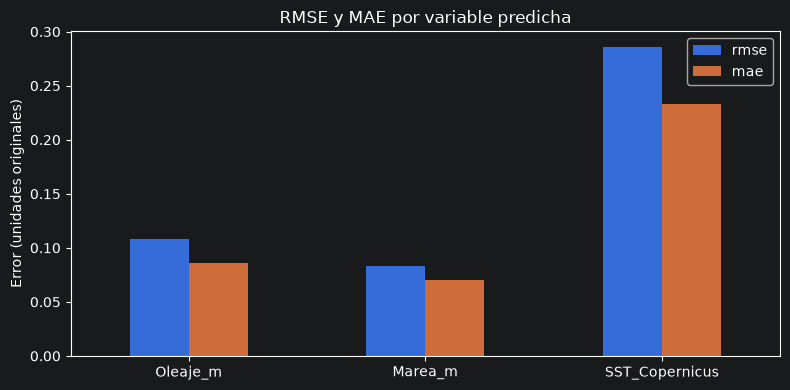

In [22]:
tabla[["rmse", "mae"]].plot(kind="bar", figsize=(8, 4), title="RMSE y MAE por variable predicha")
plt.ylabel("Error (unidades originales)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:
import os
os.makedirs(os.path.join(BASE_DIR, 'models'), exist_ok=True)

ruta_modelo = os.path.join(BASE_DIR, 'models', 'lstm_oleaje_m.keras')
modelo_oleaje.save(ruta_modelo)

print("Modelo guardado en:", ruta_modelo)
print("¿Existe?:", os.path.exists(ruta_modelo))

Modelo guardado en: C:\Users\Daniel Nájera\Documents\GitHub\OceanoIA\models\lstm_oleaje_m.keras
¿Existe?: True
